In [1]:
import sys

import polars as pl
import torch
import os
import glob

from modeling_module.data_loader.MultiPartDataModule import MultiPartDataModule
from modeling_module.data_loader.MultiPartExoDataModule import MultiPartExoDataModule

'''
pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
https://developer.nvidia.com/cuda-12-8-0-download-archive
'''

MAC_DIR = '/Users/igwanhyeong/PycharmProjects/data_research/raw_data/'
WINDOW_DIR = 'C:/Users/USER/PycharmProjects/research/raw_data/'

if sys.platform == 'win32':
    DIR = WINDOW_DIR
    print(torch.cuda.is_available())
    print(torch.cuda.device_count())
    print(torch.version.cuda)
    print(torch.__version__)
    print(torch.cuda.get_device_name(0))
    print(torch.__version__)
else:
    DIR = MAC_DIR
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

save_dir = DIR + 'fit/model_validation'

# if os.path.exists(save_dir):
#     files = glob.glob(os.path.join(save_dir, "*.pt"))
#     print(f"Deleting {len(files)} old checkpoint files...")
#     for f in files:
#         try:
#             os.remove(f)
#         except Exception as e:
#             print(f"Error deleting {f}: {e}")
# else:
#     os.makedirs(save_dir, exist_ok=True)

print("Clean up complete.")


True
1
12.8
2.9.0.dev20250716+cu128
NVIDIA GeForce RTX 5080
2.9.0.dev20250716+cu128
Clean up complete.


In [26]:
import polars as pl
import numpy as np

ETT1 = pl.read_csv(DIR + "csv/ETTh1.csv")

df = (
    ETT1
    .select(["date", "HUFL"])
    .with_columns(pl.lit("A").alias("unique_id"))
    # 원본 date 문자열을 그대로 Datetime으로 파싱
    .with_columns(
        pl.col("date").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S", strict=False).alias("date")
    )
    .sort(["unique_id", "date"])
)

# # time index
# df = df.with_columns(
#     pl.arange(0, pl.len()).over("unique_id").alias("t_idx")
# )
#
# # (1) known-future 스케줄: promo (예: 특정 시간대에만 1)
# # 하루 24시간 중 8~10시, 18~20시에 프로모션이라고 가정
# df = df.with_columns([
#     (pl.col("t_idx") % 24).alias("hour"),
# ])
#
# df = df.with_columns([
#     (
#         ((pl.col("hour") >= 8) & (pl.col("hour") <= 10)) |
#         ((pl.col("hour") >= 18) & (pl.col("hour") <= 20))
#     ).cast(pl.Int8).alias("promo_flag")
# ])
#
# # (2) calendar exo: 24h sin/cos
# df = df.with_columns([
#     ( (2*np.pi*pl.col("t_idx")/24.0).sin().cast(pl.Float32) ).alias("exo_fut_sin24"),
#     ( (2*np.pi*pl.col("t_idx")/24.0).cos().cast(pl.Float32) ).alias("exo_fut_cos24"),
# ])
#
# # (3) (중요) 타깃에 promo 효과 "주입" -> exo가 없으면 예측이 어려워지고, 있으면 쉬워짐
# # HUFL_y = HUFL + alpha*promo_flag + beta*sin24  (alpha는 체감되게 크게)
# alpha = 2.0
# beta  = 0.5
# df = df.with_columns([
#     (
#         pl.col("HUFL").cast(pl.Float32)
#         + pl.col("promo_flag").cast(pl.Float32) * pl.lit(alpha)
#         + pl.col("exo_fut_sin24").cast(pl.Float32) * pl.lit(beta)
#     ).alias("y")
# ])
#
# df.select(["date","HUFL","promo_flag","exo_fut_sin24","y"]).head(5)


In [27]:
lookback = 52
horizon = 8

data_module = MultiPartExoDataModule(
    df,
    part_col = 'unique_id',
    date_col = 'date',
    qty_col = 'HUFL',
    lookback = lookback,
    horizon = horizon,
    batch_size = 128,
    freq = 'hourly',
    shuffle = False
)

train_loader = data_module.get_train_loader()
val_loader = data_module.get_val_loader()

In [28]:
print("len(train_dataset) =", len(data_module.train_dataset))
print("len(val_dataset)   =", len(data_module.val_dataset))

train_loader = data_module.get_train_loader()
val_loader   = data_module.get_val_loader()

print("len(train_loader) =", len(train_loader))
print("len(val_loader)   =", len(val_loader))


len(train_dataset) = 13889
len(val_dataset)   = 3472
len(train_loader) = 108
len(val_loader)   = 28


In [29]:
from modeling_module.training.model_trainers.total_train import run_total_train_monthly, run_total_train_weekly, \
    run_total_train_hourly

model_dict = run_total_train_hourly(
    train_loader,
    val_loader,
    lookback = lookback,
    horizon = horizon,
    save_dir = save_dir,
    models_to_run = ['patchtst']
)


[total_train] === RUN: patchtst (hourly) ===
exogenous dimension:: 4
PatchTST Base (Hourly)
[train_patchtst] head rebuilt: d_future 4 -> 4

[train_patchtst] ===== Stage 1/2 =====
  - spike: OFF
  - epochs: 20 | lr=0.0001 | horizon_decay=False
[train_patchtst] Effective TrainingConfig:
{
  "device": "cuda",
  "lookback": 52,
  "horizon": 8,
  "epochs": 20,
  "lr": 0.0001,
  "weight_decay": 0.001,
  "t_max": 40,
  "patience": 100,
  "max_grad_norm": 30.0,
  "amp_device": "cuda",
  "loss_mode": "point",
  "point_loss": "huber",
  "huber_delta": 0.8,
  "q_star": 0.5,
  "use_cost_q_star": false,
  "Cu": 1.0,
  "Co": 1.0,
  "quantiles": [
    0.1,
    0.5,
    0.9
  ],
  "use_intermittent": true,
  "alpha_zero": 3.0,
  "alpha_pos": 1.0,
  "gamma_run": 0.3,
  "cap": null,
  "use_horizon_decay": false,
  "tau_h": 0.85,
  "val_use_weights": false,
  "spike_loss": {
    "enabled": false,
    "strategy": "mix",
    "huber_delta": 0.6,
    "asym_up_weight": 1.0,
    "asym_down_weight": 8.0,
    "

In [36]:
from modeling_module.utils.checkpoint import load_model_dict
# Load
from modeling_module.models.model_builder import (
    build_patchTST_base, build_patchTST_quantile,
)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

builders = {
    f"hourly_PatchTSTBase_L{lookback}_H{horizon}": build_patchTST_base,
    f"hourly_PatchTSTQuantile_L{lookback}_H{horizon}": build_patchTST_quantile,
}
loaded = load_model_dict(save_dir, builders, device = device)

[load] hourly_PatchTSTBase_L52_H8 ← C:/Users/USER/PycharmProjects/research/raw_data/fit/model_validation\hourly_PatchTSTBase_L52_H8.pt
{'device': 'cuda', 'lookback': 52, 'horizon': 8, 'epochs': 1, 'lr': 0.0001, 'weight_decay': 0.0001, 't_max': 10, 'patience': 50, 'max_grad_norm': 30.0, 'amp_device': 'cuda', 'loss_mode': 'point', 'point_loss': 'huber', 'huber_delta': 5.0, 'q_star': 0.5, 'use_cost_q_star': False, 'Cu': 1.0, 'Co': 1.0, 'quantiles': (0.1, 0.5, 0.9), 'use_intermittent': True, 'alpha_zero': 1.2, 'alpha_pos': 1.0, 'gamma_run': 0.6, 'cap': None, 'use_horizon_decay': False, 'tau_h': 24.0, 'val_use_weights': False, 'spike_loss': {'enabled': True, 'strategy': 'mix', 'huber_delta': 2.0, 'asym_up_weight': 2.0, 'asym_down_weight': 1.0, 'mad_k': 3.5, 'w_spike': 6.0, 'w_norm': 1.0, 'alpha_huber': 0.7, 'beta_asym': 0.3, 'mix_with_baseline': False, 'gamma_baseline': 0.2}, 'lambda_hist_scale': 0.1, 'lambda_hist_var': 0.03, 'hist_window': 12, 'anchor_last_k': 8, 'anchor_weight': 0.05, 'c_

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


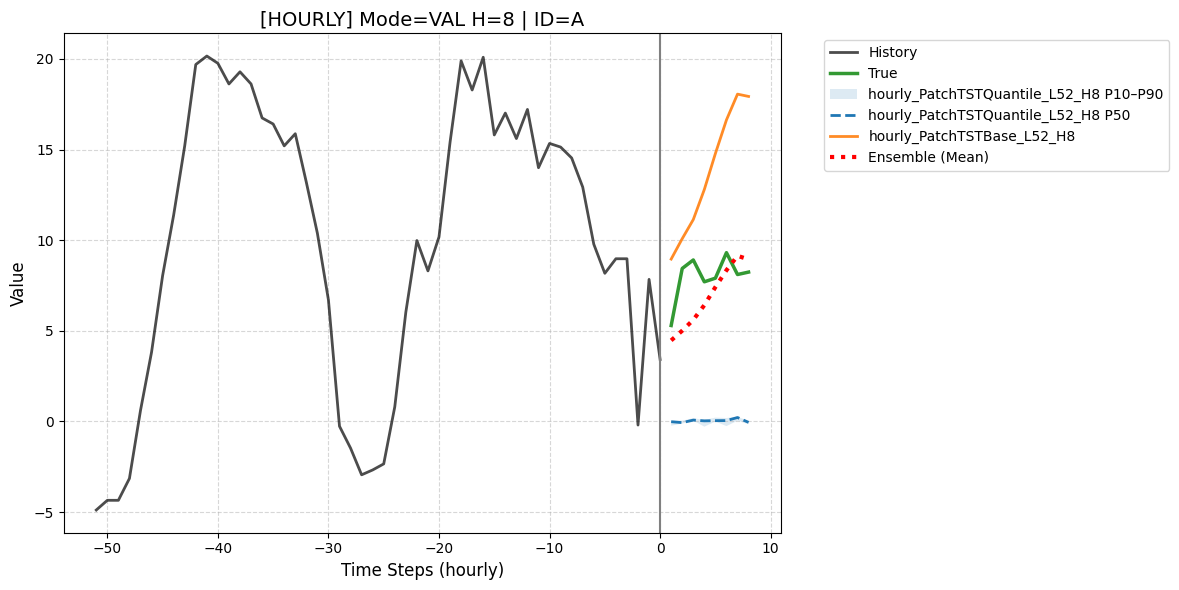

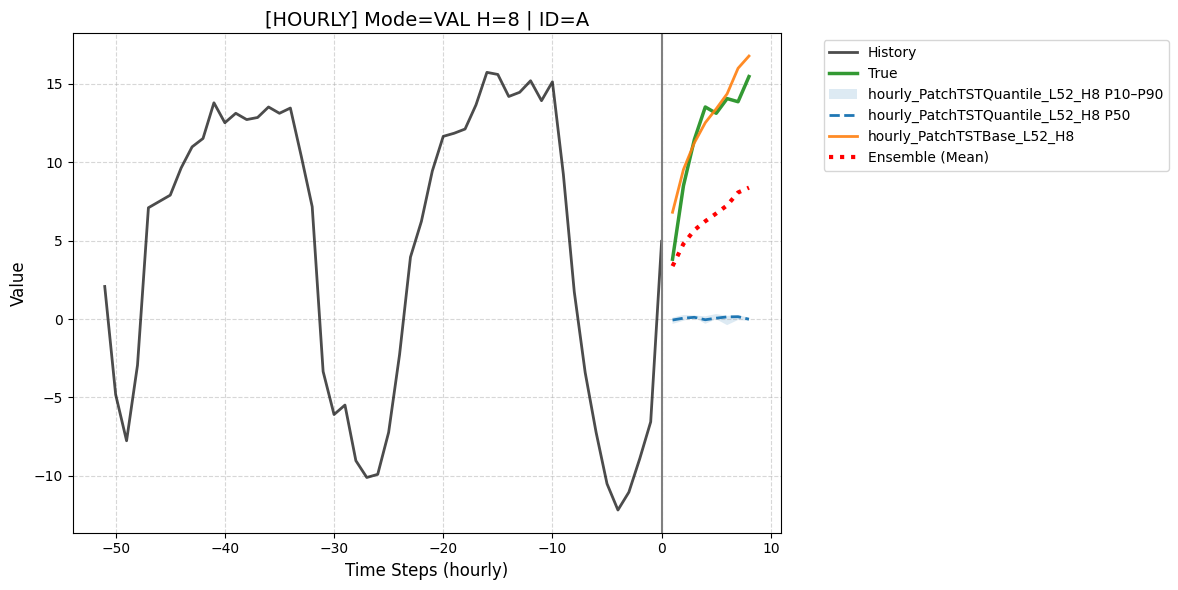

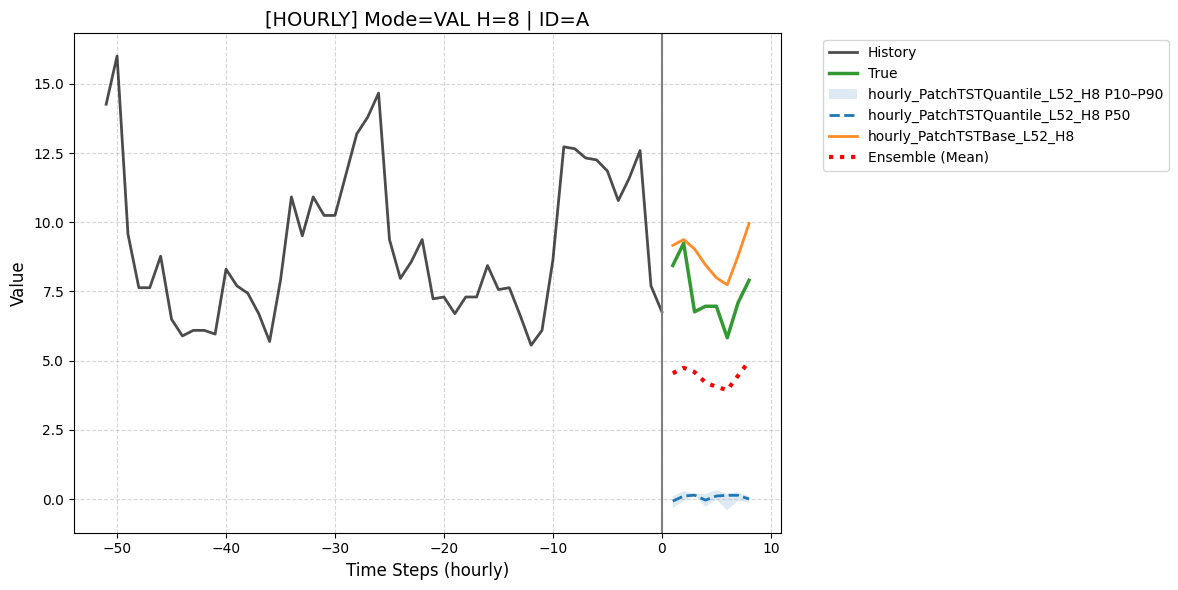

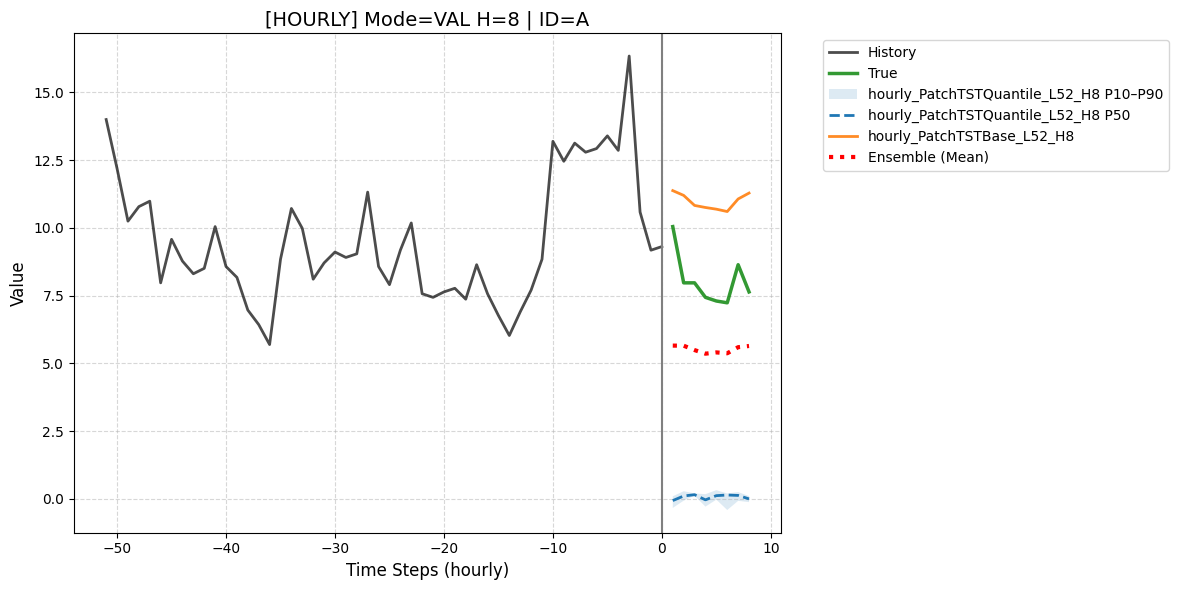

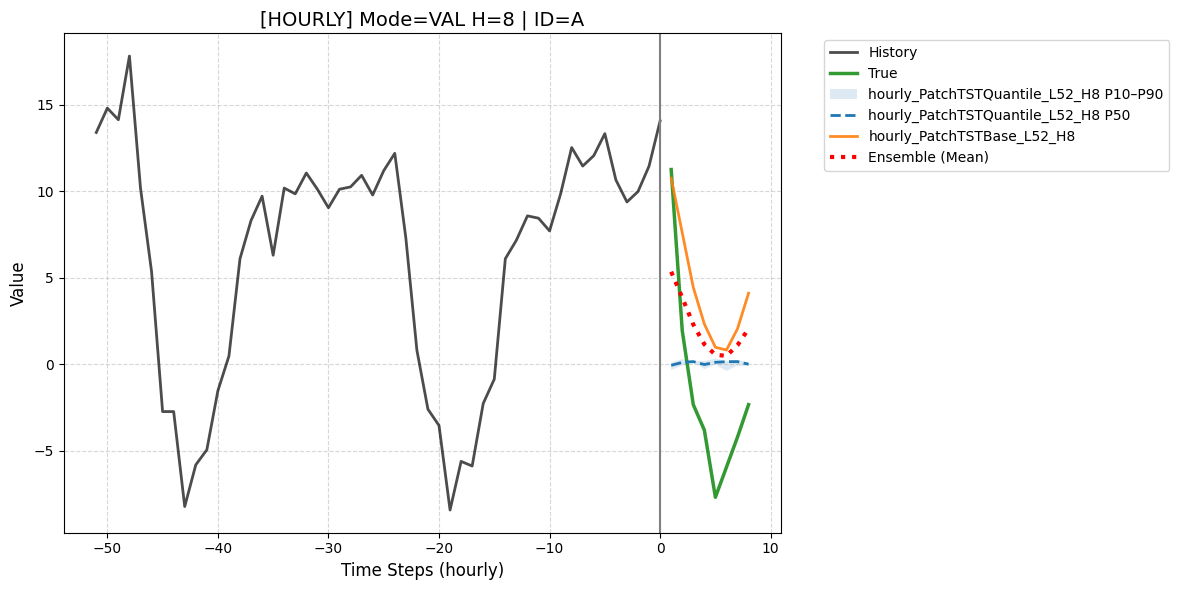

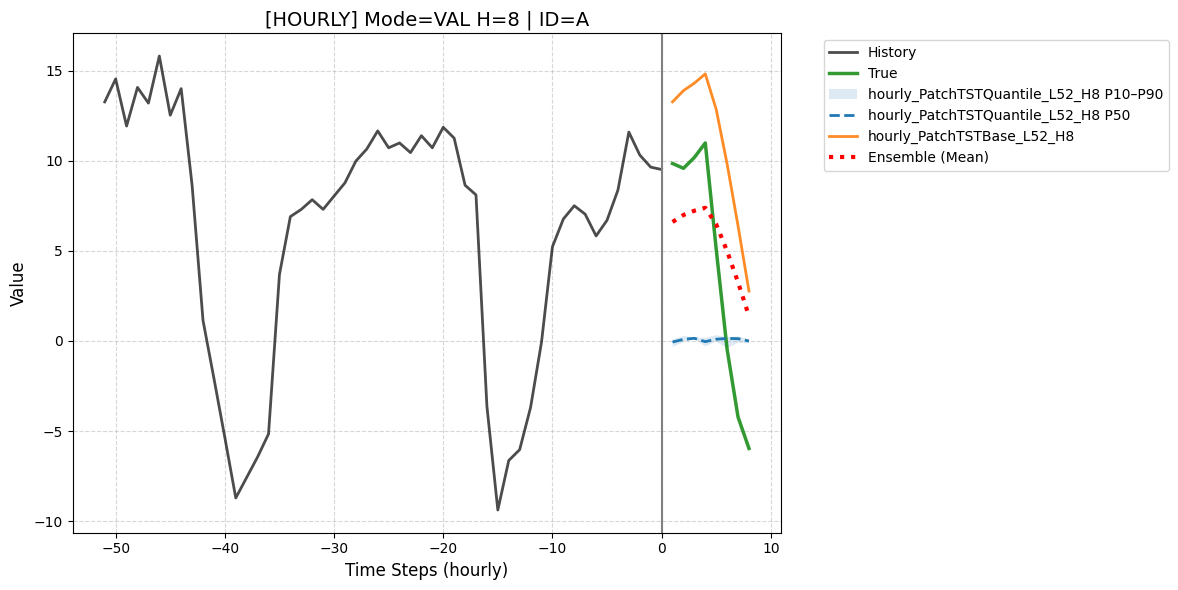

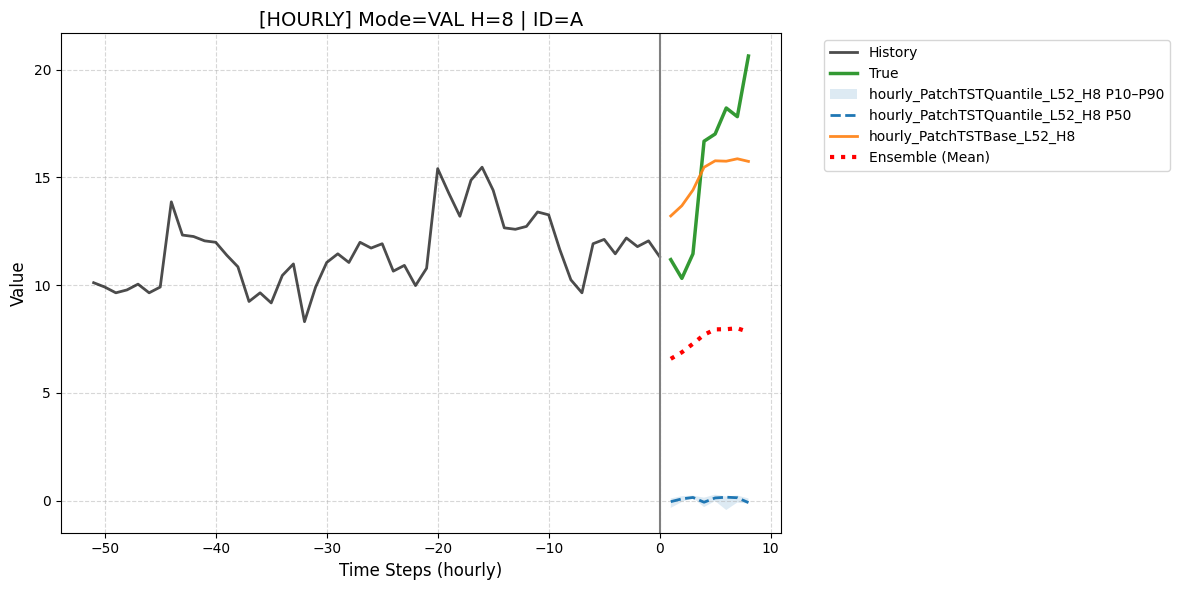

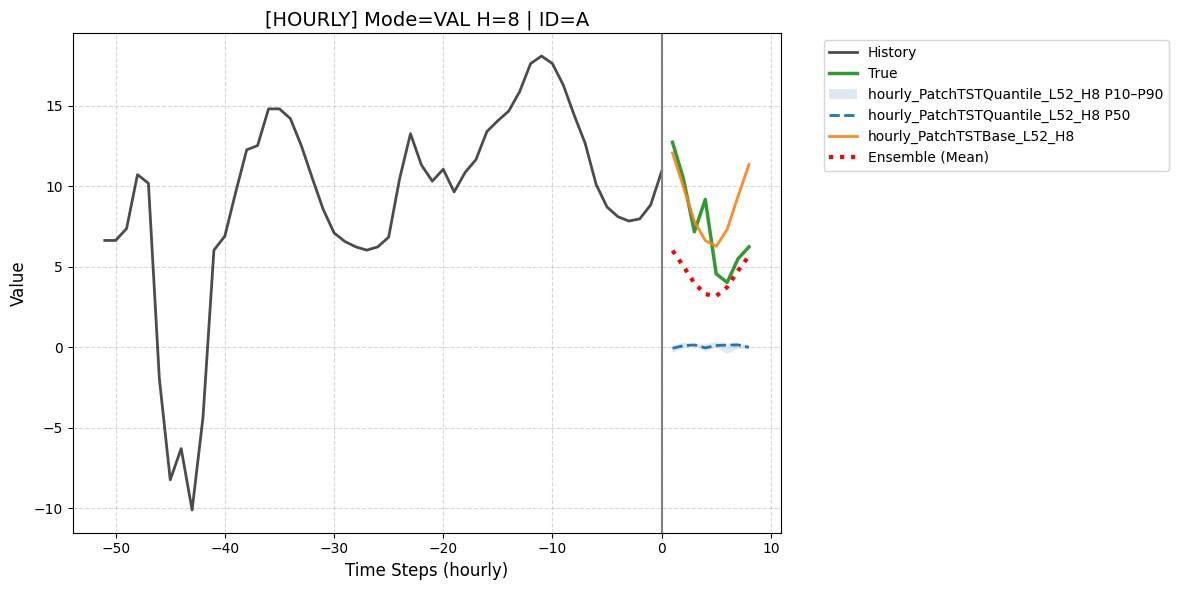

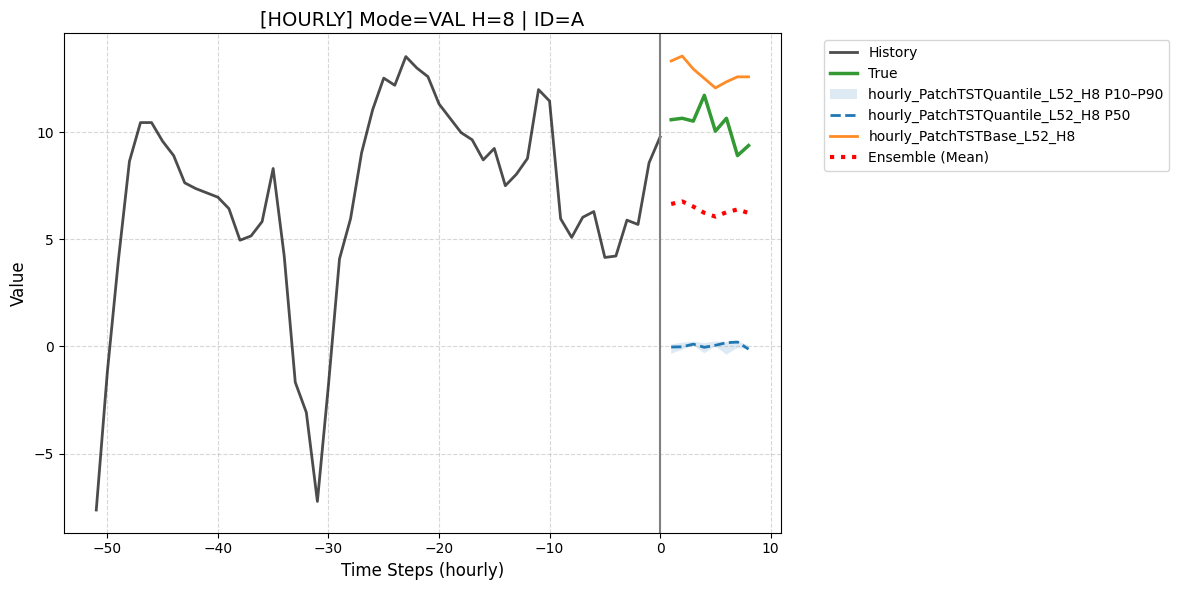

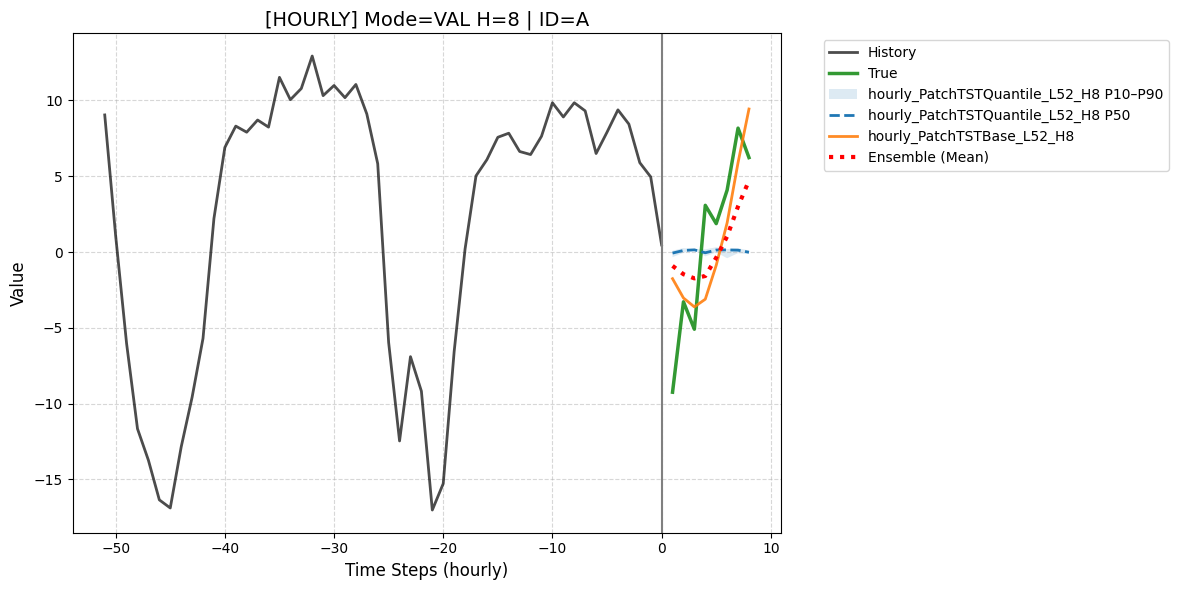

[Saved] metrics parquet: C:/Users/USER/PycharmProjects/research/raw_data/fit/model_validation/metrics.parquet


In [37]:
%load_ext autoreload
%autoreload 2

import importlib, modeling_module.utils.plot_utils as pu
import modeling_module.training.forecaster as fo
importlib.reload(pu)
importlib.reload(fo)

def my_exo_cb(start_idx: int, Hm: int, device="cuda" if torch.cuda.is_available() else "cpu"):
    # exo_dim = 2 (sin, cos)
    return fo.make_calendar_exo(start_idx, Hm, period=24, device=device)

models_for_plot = {
    name: res['model']
    for name, res in model_dict.items()
}

def my_exo_cb(start_idx: int, H: int, device="cuda"):
    # (H, 4) = hour sin/cos (2) + week sin/cos (2)
    t = torch.arange(start_idx, start_idx + H, device=device, dtype=torch.float32)
    h = torch.stack([torch.sin(2*torch.pi*t/24.0),  torch.cos(2*torch.pi*t/24.0)], dim=-1)    # (H,2)
    w = torch.stack([torch.sin(2*torch.pi*t/168.0), torch.cos(2*torch.pi*t/168.0)], dim=-1)   # (H,2)
    return torch.cat([h, w], dim=-1)  # (H,4)

pu.plot_forecast(
    models=loaded,
    loader=val_loader,
    horizon=8,
    freq="hourly",          # daily 말고 hourly 권장 (ETT)
    plan_dt=None,
    future_exo_cb=my_exo_cb,
    metrics_parquet_path = f'{save_dir}/metrics.parquet'
)

In [53]:
(pl
    .read_parquet(save_dir + '/metrics.parquet')
    .select(['sample_idx', 'model', 'y_true', 'y_pred_point', 'MAE', 'RMSE', 'sMAPE', 'WAPE'])
 ).join(
    pl.read_parquet(save_dir + '/metrics_exo.parquet')
      .select(['sample_idx', 'model', 'y_true', 'y_pred_point', 'MAE', 'RMSE', 'sMAPE', 'WAPE'])
      .rename({'y_true': 'e_y_true', 'y_pred_point': 'e_y_pred_point', 'MAE': 'e_MAE', 'RMSE': 'e_RMSE', 'sMAPE': 'e_sMAPE', 'WAPE': 'e_WAPE'})
    , on = ['sample_idx'], how = 'left'
).select(['sample_idx', 'model', 'y_true', 'y_pred_point', 'e_y_pred_point', 'MAE', 'e_MAE', 'RMSE', 'e_RMSE', 'sMAPE', 'e_sMAPE', 'WAPE', 'e_WAPE']).unique(subset = ['sample_idx', 'model'])

sample_idx,model,y_true,y_pred_point,e_y_pred_point,MAE,e_MAE,RMSE,e_RMSE,sMAPE,e_sMAPE,WAPE,e_WAPE
i64,str,list[f64],list[f64],list[f64],f64,f64,f64,f64,f64,f64,f64,f64
7,"""hourly_PatchTSTBase_L52_H8""","[12.726, 10.449, … 6.229]","[12.070307, 9.956302, … 11.343987]","[12.946499, 11.473336, … 13.262148]",2.29154,3.270387,2.795768,4.066086,0.313795,0.40698,0.306494,0.437415
8,"""hourly_PatchTSTBase_L52_H8""","[10.583, 10.65, … 9.377]","[13.323889, 13.555085, … 12.583464]","[12.766737, 13.077221, … 11.706774]",2.433942,1.729205,2.580388,1.926008,0.213317,0.156407,0.236156,0.167778
7,"""hourly_PatchTSTQuantile_L52_H8""","[12.726, 10.449, … 6.229]","[-0.067768, 0.094552, … -0.007547]","[12.946499, 11.473336, … 13.262148]",7.4144,3.270387,7.965993,4.066086,1.946052,0.40698,0.991677,0.437415
2,"""hourly_PatchTSTQuantile_L52_H8""","[8.439, 9.243, … 7.904]","[-0.075796, 0.107934, … 0.000427]","[8.68737, 9.199725, … 8.516506]",7.337326,0.637303,7.410501,0.906255,1.955751,0.084808,0.991363,0.086107
6,"""hourly_PatchTSTBase_L52_H8""","[11.186, 10.315, … 20.629999]","[13.210413, 13.686142, … 15.741817]","[12.383286, 12.798387, … 15.597746]",2.514547,2.470834,2.761918,2.709733,0.169602,0.163966,0.163134,0.160298
…,…,…,…,…,…,…,…,…,…,…,…,…
5,"""hourly_PatchTSTQuantile_L52_H8""","[9.846, 9.578, … -5.961]","[-0.058652, 0.089941, … -0.003669]","[12.169291, 13.250288, … 4.825105]",7.044573,6.156571,7.826017,7.090274,1.978473,0.972934,1.000472,0.874358
8,"""hourly_PatchTSTQuantile_L52_H8""","[10.583, 10.65, … 9.377]","[-0.027545, -0.017427, … -0.125561]","[12.766737, 13.077221, … 11.706774]",10.265844,1.729205,10.300359,1.926008,1.973178,0.156407,0.996055,0.167778
4,"""hourly_PatchTSTQuantile_L52_H8""","[11.253, 1.942, … -2.344]","[-0.070744, 0.099685, … -0.004366]","[10.380899, 7.209314, … 6.132899]",5.006934,8.180638,5.861534,8.87633,1.971353,1.653973,1.011885,1.65328


In [46]:
(pl.read_parquet(save_dir + '/metrics_exo.parquet')
      .select(['sample_idx', 'model', 'y_true', 'y_pred_point', 'MAE', 'RMSE', 'sMAPE', 'WAPE'])
      .rename({'y_true': 'e_y_true', 'y_pred_point': 'e_y_pred_point', 'MAE': 'e_MAE', 'RMSE': 'e_RMSE', 'sMAPE': 'e_sMAPE', 'WAPE': 'e_WAPE'}))

sample_idx,model,e_y_true,e_y_pred_point,e_MAE,e_RMSE,e_sMAPE,e_WAPE
i64,str,list[f64],list[f64],f64,f64,f64,f64
0,"""hourly_PatchTSTBase_L52_H8_exo""","[5.291, 8.439, … 8.239]","[11.04512, 12.438972, … 20.019516]",7.880597,8.321643,0.649744,0.986632
0,"""hourly_PatchTSTQuantile_L52_H8…","[5.291, 8.439, … 8.239]","[0.088789, -0.071346, … 0.121381]",7.950855,8.034916,1.959845,0.995428
1,"""hourly_PatchTSTBase_L52_H8_exo""","[3.818, 8.506, … 15.472]","[7.401834, 9.542945, … 15.860813]",1.01316,1.46754,0.125837,0.086374
1,"""hourly_PatchTSTQuantile_L52_H8…","[3.818, 8.506, … 15.472]","[0.075997, -0.081598, … 0.172828]",11.714905,12.244328,1.970715,0.998724
2,"""hourly_PatchTSTBase_L52_H8_exo""","[8.439, 9.243, … 7.904]","[8.68737, 9.199725, … 8.516506]",0.637303,0.906255,0.084808,0.086107
…,…,…,…,…,…,…,…
7,"""hourly_PatchTSTQuantile_L52_H8…","[12.726, 10.449, … 6.229]","[0.076182, -0.080101, … 0.133933]",7.468982,7.995733,1.949705,0.998978
8,"""hourly_PatchTSTBase_L52_H8_exo""","[10.583, 10.65, … 9.377]","[12.766737, 13.077221, … 11.706774]",1.729205,1.926008,0.156407,0.167778
8,"""hourly_PatchTSTQuantile_L52_H8…","[10.583, 10.65, … 9.377]","[0.078731, -0.089181, … 0.118975]",10.288286,10.313201,1.972428,0.998233
